In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from multicam.multicam import MultiCAM, MultiCamSampling
from multicam.qt import qt
from multicam_tng.multicam2 import multicam_prediction
from scipy.stats import spearmanr

from multicam_tng.utils import get_an_from_mpeak_mah
from astropy.table import Table


TNG_H = 0.6774
COLOR_CUT = 1.0  # Changed a little bit


from halotools.mock_observables import return_xyz_formatted_array, tpcf_jackknife, tpcf


In [2]:
metadata = pd.read_csv(
    "../../data/tng300-1-table.csv"
)  # this ist just metadata which sims share
redshift_snaps = metadata["Redshift"].values
scales = 1 / (1 + redshift_snaps)
scales.shape

(100,)

In [3]:
def generate_randoms(Lbox, number):
    """Generate randoms to be used for tpcf_jackknife
    Args:
        Lbox: size of TNG simulation box
        number: desired number of randoms, i.e. 10,000
    Return:
        Nran: xyz formatted array of uniform random variables
    """
    Xran = np.random.uniform(0, Lbox, number)
    Yran = np.random.uniform(0, Lbox, number)
    Zran = np.random.uniform(0, Lbox, number)
    Nran = return_xyz_formatted_array(Xran, Yran, Zran)
    return Nran


In [4]:
# -----------------------------
# Load data
# -----------------------------
hydro_raw = Table.read("../../data/hydro_final.ecsv")
len(hydro_raw)

101364

In [5]:
# Stellar mass cut
# NOTE: this cut can potentially bias the results so we avoid it
# although Ismael and Phil checked that it does not really matter.
# hydro_full = hydro_full[
#     hydro_full['StellarMass'] >= (1.4e8 * TNG_H)
# ]

# Add z12
hydro_raw["z12"] = (1 / hydro_raw["a12"]) - 1

In [6]:
# cut based on mpeak
log_mpeak = np.log10(hydro_raw["mpeak"])
mpeak_cut_mask = (log_mpeak > 11) & (log_mpeak < 12)
hydro_full = hydro_raw[mpeak_cut_mask]
len(hydro_full)

11310

In [7]:
# -----------------------------
# Define SHAM baseline
# -----------------------------
log10_mpeak = np.log10(hydro_full["mpeak"].data)
log10_stellar_mass = np.log10(hydro_full["stellar_mass"].data)

print(len(log10_mpeak), len(log10_stellar_mass))
assert len(log10_mpeak) == len(log10_stellar_mass)

# SHAM mean relation (NO scatter), also defines SHMR
logmstar_sham = qt(log10_mpeak, log10_stellar_mass)

11310 11310


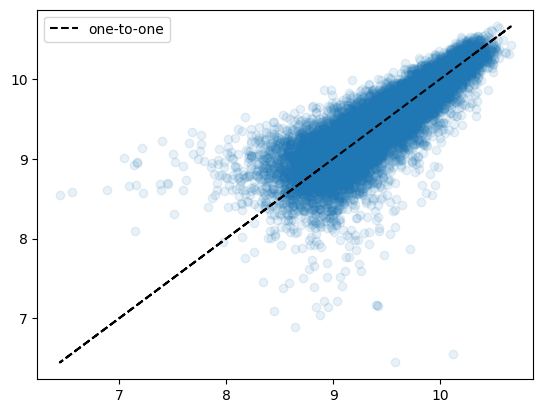

In [8]:
# what does the SHMR look like
plt.scatter(logmstar_sham, log10_stellar_mass, alpha=0.1)
plt.plot(log10_stellar_mass, log10_stellar_mass, ls="--", c="k", label="one-to-one")
plt.legend()

In [9]:
star_mask = (log10_stellar_mass > 9.5) & (log10_stellar_mass < 10.2)
hydro_mstar_cut = hydro_full[star_mask]

sham_mask = (logmstar_sham > 9.5) & (logmstar_sham < 10.2)
hydro_mstar_pred = hydro_full[sham_mask]


len(hydro_mstar_cut), len(hydro_mstar_pred)


(4001, 4001)

In [ ]:
# CAM prediction for color
# possibly resample
# _color = np.random.choice(hydro_mstar_cut['color'].data, size=len(hydro_mstar_cut), replace=True)
_color = hydro_mstar_cut["color"]
color_cam_pred = qt(hydro_mstar_pred["z12"].data, _color)
color_cam_pred.shape

(4001,)

In [ ]:
# MultiCAM prediction for color based on a_n
# ns = np.linspace(0, 1, n_fracs)
ns = np.array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9])
an = get_an_from_mpeak_mah(hydro_mstar_pred["mpeak_mah"].data, scales=scales, ns=ns)
an.shape

(4001, 9)

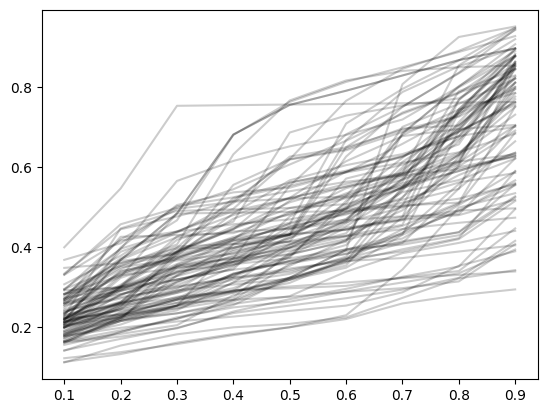

In [47]:
idx = np.random.randint(an.shape[0], size=(100,))
for ii in idx:
    plt.plot(ns, an[ii], c="k", alpha=0.2)

In [ ]:

x = an
y = hydro_mstar_cut["color"].reshape(-1, 1)

model = MultiCAM(ns.shape[0], 1)
model.fit(x, y)
color_multicam_pred = model.predict(x)[:, 0]
color_multicam_pred.shape

(4001,)

In [58]:
# _color = hydro_mstar_cut["color"]

# x = an
# y = _color.reshape(-1, 1)

# color_multicam_pred = multicam_prediction(x, x, y)[:, 0]
# color_multicam_pred.shape

(array([  0.,   0.,   0.,   1.,   2.,   4.,   5.,  17.,  27.,  49.,  80.,
        132., 189., 257., 299., 338., 315., 286., 249., 200., 179., 151.,
        122., 105.,  69.,  68.,  83., 129., 200., 243., 137.,  52.,  11.,
          2.,   0.,   0.,   0.,   0.,   0.,   0.]),
 array([0.2   , 0.2325, 0.265 , 0.2975, 0.33  , 0.3625, 0.395 , 0.4275,
        0.46  , 0.4925, 0.525 , 0.5575, 0.59  , 0.6225, 0.655 , 0.6875,
        0.72  , 0.7525, 0.785 , 0.8175, 0.85  , 0.8825, 0.915 , 0.9475,
        0.98  , 1.0125, 1.045 , 1.0775, 1.11  , 1.1425, 1.175 , 1.2075,
        1.24  , 1.2725, 1.305 , 1.3375, 1.37  , 1.4025, 1.435 , 1.4675,
        1.5   ]),
 [<matplotlib.patches.Polygon at 0x11aa7d1d0>])

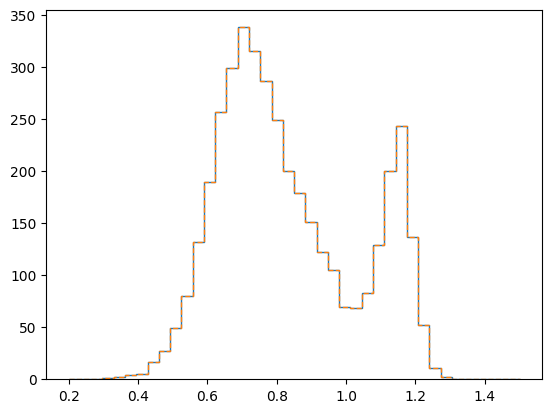

In [59]:
bins = np.linspace(0.2, 1.5, 41)


plt.hist(hydro_mstar_cut["color"], bins=bins, histtype="step", ls="-")
plt.hist(color_multicam_pred, bins=bins, histtype="step", ls="--")

In [60]:
(
    spearmanr(hydro_mstar_cut["color"], color_cam_pred),
    spearmanr(hydro_mstar_cut["color"], color_multicam_pred),
)

(SignificanceResult(statistic=np.float64(0.27324055240914796), pvalue=np.float64(1.9151525917766075e-69)),
 SignificanceResult(statistic=np.float64(0.3751545817400615), pvalue=np.float64(6.415408640841172e-134)))

## Clustering (CAM)

In [61]:
Lbox = 110.7 * TNG_H  # TNG box size in Mpc /h
rbins = np.logspace(np.log10(0.1), np.log10(24.9), 16)
rbin_centers = 0.5 * (rbins[1:] + rbins[:-1])
randoms = generate_randoms(Lbox, 50000)
randoms.shape

(50000, 3)

In [62]:
true_color = hydro_mstar_cut["color"]
red_true = hydro_mstar_cut[true_color > COLOR_CUT]
blue_true = hydro_mstar_cut[true_color <= COLOR_CUT]


red_pred = hydro_mstar_pred[color_cam_pred > COLOR_CUT]
blue_pred = hydro_mstar_pred[color_cam_pred <= COLOR_CUT]

multicam_red_pred = hydro_mstar_pred[color_multicam_pred > COLOR_CUT]
multicam_blue_pred = hydro_mstar_pred[color_multicam_pred <= COLOR_CUT]

In [63]:
len(red_pred), len(red_true), len(multicam_red_pred)

(954, 954, 954)

In [64]:
xyz_red = return_xyz_formatted_array(
    red_true["x"].data, red_true["y"].data, red_true["z"].data
)
xyz_blue = return_xyz_formatted_array(
    blue_true["x"].data, blue_true["y"].data, blue_true["z"].data
)


xi_red_true = tpcf(xyz_red, rbins, randoms=randoms, period=Lbox, num_threads="max")

xi_blue_true = tpcf(xyz_blue, rbins, randoms=randoms, period=Lbox, num_threads="max")


In [65]:
xyz_red = return_xyz_formatted_array(
    red_pred["x"].data, red_pred["y"].data, red_pred["z"].data
)
xyz_blue = return_xyz_formatted_array(
    blue_pred["x"].data, blue_pred["y"].data, blue_pred["z"].data
)


xi_red_cam = tpcf(xyz_red, rbins, randoms=randoms, period=Lbox, num_threads="max")

xi_blue_cam = tpcf(xyz_blue, rbins, randoms=randoms, period=Lbox, num_threads="max")


In [66]:
xyz_red = return_xyz_formatted_array(
    multicam_red_pred["x"].data,
    multicam_red_pred["y"].data,
    multicam_red_pred["z"].data,
)
xyz_blue = return_xyz_formatted_array(
    multicam_blue_pred["x"].data,
    multicam_blue_pred["y"].data,
    multicam_blue_pred["z"].data,
)


xi_red_multicam = tpcf(xyz_red, rbins, randoms=randoms, period=Lbox, num_threads="max")

xi_blue_multicam = tpcf(
    xyz_blue, rbins, randoms=randoms, period=Lbox, num_threads="max"
)


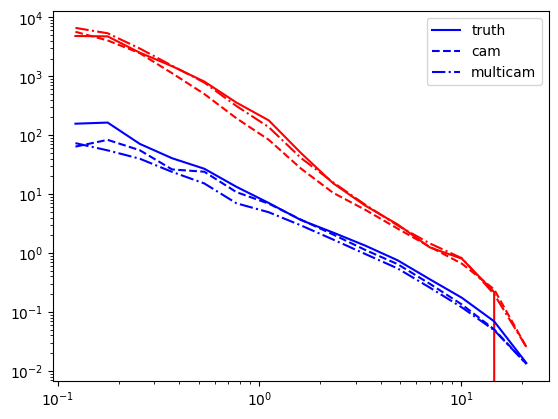

In [72]:
plt.loglog(rbin_centers, xi_red_true, c="r")
plt.loglog(rbin_centers, xi_blue_true, c="b", label="truth")


plt.loglog(rbin_centers, xi_red_cam, c="r", ls="--")
plt.loglog(rbin_centers, xi_blue_cam, c="b", ls="--", label="cam")

plt.loglog(rbin_centers, xi_red_multicam, c="r", ls="-.")
plt.loglog(rbin_centers, xi_blue_multicam, c="b", ls="-.", label="multicam")

plt.legend()

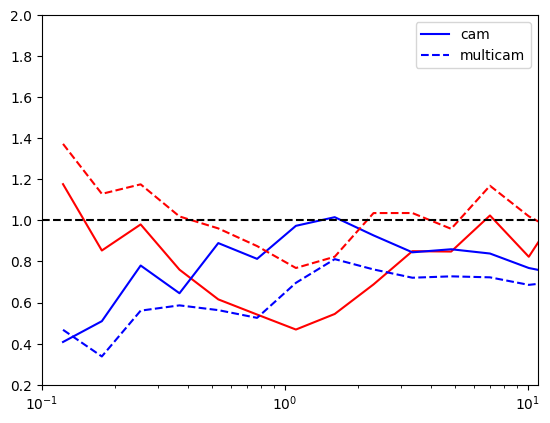

In [68]:
plt.semilogx(rbin_centers, xi_red_cam / xi_red_true, c="r", ls="-")
plt.semilogx(rbin_centers, xi_blue_cam / xi_blue_true, c="b", ls="-", label="cam")

plt.semilogx(rbin_centers, xi_red_multicam / xi_red_true, c="r", ls="--")
plt.semilogx(
    rbin_centers, xi_blue_multicam / xi_blue_true, c="b", ls="--", label="multicam"
)

plt.axhline(1.0, ls="--", c="k")

plt.xlim(0.1, 11)
plt.ylim(0.2, 2.0)

plt.legend()

# i think this reproduces haley's results
# doesn't seem to get much affected by adding scatter or not...
# NOTE: double check, but mpeak mass bin cut at the beginning does not seem to affect output